In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Load the Airbnb listings dataset from a CSV file
airbnb = pd.read_csv("/Users/Hiro/LCR/01_materials/notebooks/dataset/listings.csv")

In [11]:
# Calculate and return the average price from the "price" column in the Airbnb dataset
airbnb["price"].mean()

np.float64(249.16526273565984)

In [12]:
# Set the random seed to 100 for reproducibility
np.random.seed(100)

In [16]:
# Randomly select a sample of 40 rows from the Airbnb dataset and calculate the average price from the "price" column
airbnb.sample(n=40)["price"].mean()

np.float64(232.4)

In [19]:
# Initialize an empty list to store the samples

sample_list = []

for i in range(20_000):
    sample = airbnb.sample(n=40)
    sample = sample.assign(replicate = i)
    sample_list.append(sample)
samples = pd.concat(sample_list)

In [20]:
samples

,id,neighbourhood,room_type,accommodates,bathrooms,bedrooms,beds,price,replicate
2134,4.425253e+07,Downtown,Entire home/apt,4,2.0,2.0,2.0,168,0
2007,4.204409e+07,Downtown,Entire home/apt,6,2.0,2.0,2.0,160,0
4413,9.110000e+17,Fairview,Entire home/apt,4,1.0,1.0,2.0,406,0
3315,6.940000e+17,Dunbar Southlands,Private room,2,1.0,1.0,1.0,250,0
1569,3.456737e+07,Hastings-Sunrise,Entire home/apt,2,1.0,1.0,1.0,140,0
...,...,...,...,...,...,...,...,...,...
979,2.330587e+07,Riley Park,Entire home/apt,4,1.0,1.0,2.0,117,19999
4077,8.620000e+17,West End,Entire home/apt,4,1.5,2.0,2.0,336,19999
4869,9.760000e+17,Oakridge,Private room,2,1.0,1.0,2.0,790,19999
2621,5.256332e+07,Downtown Eastside,Entire home/apt,2,1.0,1.0,1.0,198,19999


In [26]:
sample_estimate = samples.groupby("replicate")["price"].mean().reset_index(name="sample_mean")

In [27]:
sample_estimate

,replicate,sample_mean
0,0,202.550
1,1,228.475
2,2,221.500
3,3,229.950
4,4,217.650
...,...,...
19995,19995,228.600
19996,19996,241.175
19997,19997,220.625
19998,19998,199.700


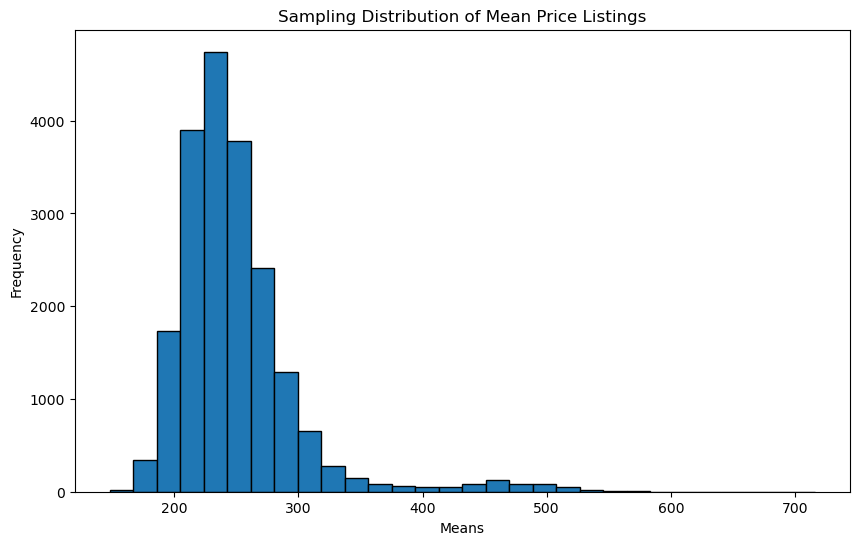

In [30]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(sample_estimate['sample_mean'], bins=30, edgecolor='black')

# Add titles and labels
plt.title('Sampling Distribution of Mean Price Listings')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [29]:
np.random.seed(1234)
one_sample = airbnb.sample(n=40)
one_sample["price"].mean()

np.float64(219.85)

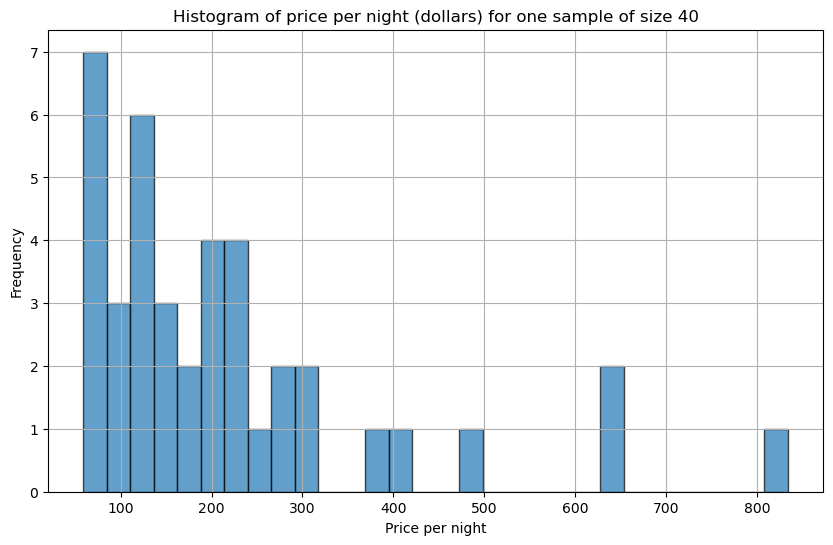

In [31]:
# Histogram of price per night (dollars) for one sample of size 40.
plt.figure(figsize=(10, 6))
plt.hist(one_sample['price'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of price per night (dollars) for one sample of size 40')
plt.xlabel('Price per night')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()


In [33]:
boot1 = one_sample.sample(frac = 1, replace = True)

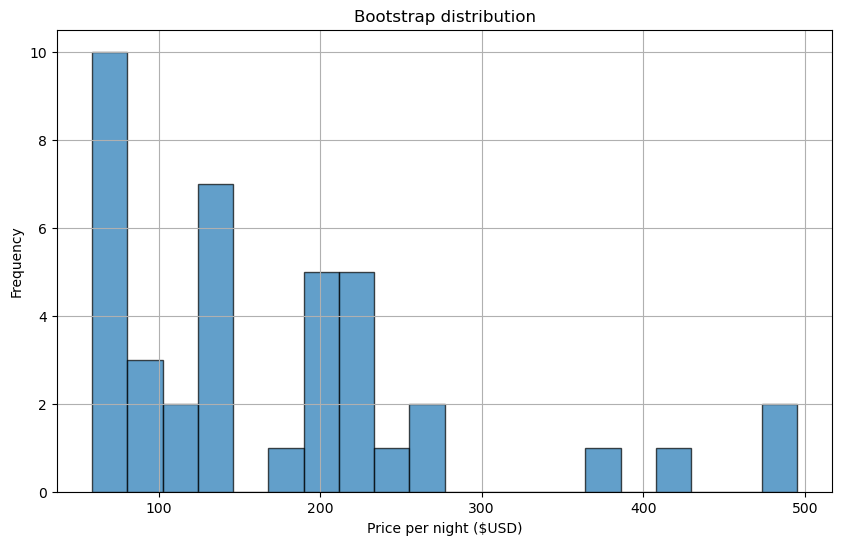

In [34]:
# Plot the histogram of the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(boot1['price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Bootstrap distribution')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [36]:
boot1["price"].mean()

np.float64(175.425)

In [38]:
bootstrap_samples = []
for i in range(20_000):
    sample = one_sample.sample (frac=1, replace=True)
    sample = sample.assign(replicate = i)
    bootstrap_samples.append(sample)
boot2000 = pd.concat(bootstrap_samples)

In [39]:
boot_mean = boot2000.groupby("replicate")["price"].mean().reset_index(name="mean_price")
boot_mean

,replicate,mean_price
0,0,208.250
1,1,205.800
2,2,183.925
3,3,211.600
4,4,239.475
...,...,...
19995,19995,176.725
19996,19996,217.450
19997,19997,204.600
19998,19998,216.900


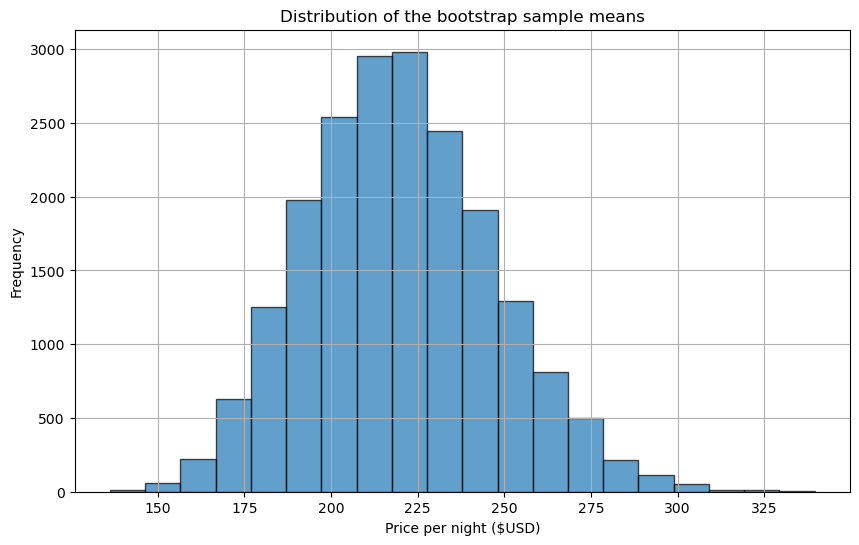

In [40]:
plt.figure(figsize=(10, 6))
plt.hist(boot_mean['mean_price'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Distribution of the bootstrap sample means')
plt.xlabel('Price per night ($USD)')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()


In [41]:
ci_bounds = boot_mean["mean_price"].quantile([0.025,0.975])
ci_bounds

0.025    171.248750
0.975    276.300625
Name: mean_price, dtype: float64